In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

Path('../outputs/figures').mkdir(parents=True, exist_ok=True)

# Colour palette 
NAVY   = '#08306b'
BLUE   = '#2171b5'
LBLUE  = '#9ecae1'
RED    = '#d62728'
ORANGE = '#e6550d'
GREEN  = '#31a354'
PURPLE = '#756bb1'
GREY   = '#636363'
CAT_COLORS = ['#08306b','#2171b5','#4292c6','#6baed6','#9ecae1',
              '#e6550d','#fd8d3c','#31a354','#756bb1','#bcbddc']

# Global matplotlib style 
plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Arial', 'Helvetica Neue', 'DejaVu Sans'],
    'font.size':          11,
    'axes.titlesize':     15,
    'axes.titleweight':   'bold',
    'axes.titlepad':      12,
    'axes.labelsize':     12,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
    'axes.grid':          True,
    'grid.color':         '#e0e0e0',
    'grid.linewidth':     0.6,
    'axes.axisbelow':     True,
    'xtick.major.size':   0,
    'ytick.major.size':   0,
    'legend.frameon':     False,
    'legend.fontsize':    10,
    'figure.facecolor':   'white',
    'axes.facecolor':     '#fafafa',
    'savefig.dpi':        300,
    'savefig.bbox':       'tight',
    'savefig.facecolor':  'white',
})

In [33]:
BASE = Path('..')

df     = pd.read_csv(BASE / 'data/processed/ai_companies_cleaned.csv')
rounds = pd.read_csv(BASE / 'data/raw/latestrounds_funding_rounds.csv')

df['last_funding_date'] = pd.to_datetime(df['last_funding_date'], errors='coerce')
df['founded_date']      = pd.to_datetime(df['founded_date'],      errors='coerce')
rounds['date']          = pd.to_datetime(rounds['date'],           errors='coerce')

print(f'Companies    : {len(df):,}')
print(f'Rounds       : {len(rounds):,}')
print(f'Total funding: ${df["total_funding_millions"].sum()/1e3:,.0f}B')
print(f'Unicorns     : {df["is_unicorn"].sum()}')
print(f'Mega-rounds  : {df["has_mega_round"].sum()} companies raised $50M+')
print(f'Countries    : {df["headquarters_country"].nunique()}')

Companies    : 502
Rounds       : 1,063
Total funding: $387B
Unicorns     : 25
Mega-rounds  : 175 companies raised $50M+
Countries    : 40


In [35]:
def parse_amount_m(s):
    """Parse '$2.1M', '$500K', '$1.2B' -> float (millions). NaN for Undisclosed."""
    if pd.isna(s) or str(s).strip() in ('Undisclosed', ''):
        return np.nan
    s = str(s).strip().replace('$', '').replace(',', '').upper()
    try:
        if 'B' in s:
            return float(s.replace('B', '')) * 1_000
        elif 'M' in s:
            return float(s.replace('M', ''))
        elif 'K' in s:
            return float(s.replace('K', '')) / 1_000
        return float(s)
    except (ValueError, AttributeError):
        return np.nan

rounds['amount_m'] = rounds['amount'].apply(parse_amount_m)
rounds['year']     = rounds['date'].dt.year

disclosed = rounds['amount_m'].notna()
print(f'Amounts parsed : {disclosed.sum():,} / {len(rounds):,} ({disclosed.mean():.0%})')
print(f'Largest round  : ${rounds["amount_m"].max()/1e3:.1f}B')
print(f'Median round   : ${rounds["amount_m"].median():.1f}M')

Amounts parsed : 1,006 / 1,063 (95%)
Largest round  : $110.0B
Median round   : $20.0M


---
## Chart 1 — The AI Funding Explosion (2020–2026)

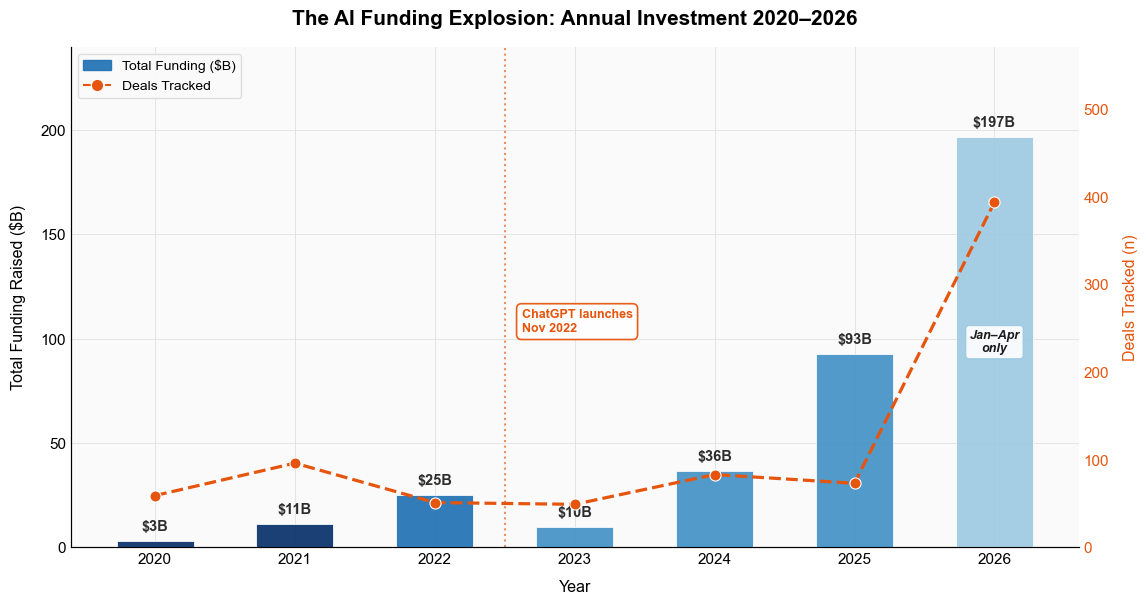

Saved: outputs/figures/01_funding_timeseries.png


In [38]:
annual = (
    rounds[rounds['year'].between(2020, 2026)]
    .groupby('year')
    .agg(total_m=('amount_m', 'sum'), deals=('amount_m', 'count'))
    .reset_index()
)
annual['total_b'] = annual['total_m'] / 1_000

bar_colors = [
    NAVY      if y <= 2021 else
    BLUE      if y == 2022 else
    '#4292c6' if y <= 2025 else
    '#9ecae1'
    for y in annual['year']
]

fig, ax1 = plt.subplots(figsize=(12, 6.5))
fig.patch.set_facecolor('white')
fig.subplots_adjust(top=0.90, bottom=0.13, left=0.08, right=0.92)

bars = ax1.bar(
    annual['year'], annual['total_b'],
    color=bar_colors, width=0.55,
    alpha=0.92, zorder=3, edgecolor='white', linewidth=0.6
)

# Value labels above bars (with extra clearance for partial-year flag on 2026)
for bar, val, yr in zip(bars, annual['total_b'], annual['year']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + annual['total_b'].max() * 0.018,
        f'${val:.0f}B', ha='center', va='bottom',
        fontsize=10.5, fontweight='bold', color='#2c2c2c'
    )

# Partial-year flag inside the 2026 bar (no collision)
partial_val = annual.loc[annual['year'] == 2026, 'total_b'].values
if len(partial_val):
    ax1.text(
        2026, partial_val[0] / 2,
        'Jan–Apr\nonly', ha='center', va='center',
        fontsize=9, color='#1a1a1a', style='italic',
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#9ecae1', alpha=0.92)
    )

# Deal-count overlay
ax2 = ax1.twinx()
ax2.plot(annual['year'], annual['deals'], 'o--',
         color=ORANGE, linewidth=2.3, markersize=8, zorder=4,
         markeredgecolor='white', markeredgewidth=0.8)
ax2.set_ylabel('Deals Tracked (n)', color=ORANGE, fontsize=11.5, labelpad=10)
ax2.tick_params(axis='y', labelcolor=ORANGE)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_color(ORANGE)
ax2.set_ylim(0, annual['deals'].max() * 1.45)
ax2.grid(False)

# ChatGPT marker
ax1.axvline(2022.5, color=ORANGE, linestyle=':', linewidth=1.5, alpha=0.65, zorder=2)
ax1.annotate(
    'ChatGPT launches\nNov 2022',
    xy=(2022.5, annual['total_b'].max() * 0.55),
    xytext=(2022.62, annual['total_b'].max() * 0.55),
    fontsize=9, color=ORANGE, fontweight='bold', ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=ORANGE, alpha=0.95, linewidth=1.2)
)

ax1.set_xlabel('Year', labelpad=10, fontsize=11.5)
ax1.set_ylabel('Total Funding Raised ($B)', labelpad=10, fontsize=11.5)
ax1.set_title('The AI Funding Explosion: Annual Investment 2020–2026', pad=16)
ax1.set_xticks(annual['year'])
ax1.set_ylim(0, annual['total_b'].max() * 1.22)

blue_patch  = mpatches.Patch(color=BLUE, alpha=0.92, label='Total Funding ($B)')
orange_line = plt.Line2D([0], [0], color=ORANGE, marker='o',
                         linestyle='--', label='Deals Tracked', markersize=7)
ax1.legend(handles=[blue_patch, orange_line], loc='upper left',
           fontsize=10, framealpha=0.95, frameon=True, edgecolor='#dddddd')

plt.savefig('../outputs/figures/01_funding_timeseries.png')
plt.show()
print('Saved: outputs/figures/01_funding_timeseries.png')

---
## Chart 2 — Top 10 Best-Funded AI Companies

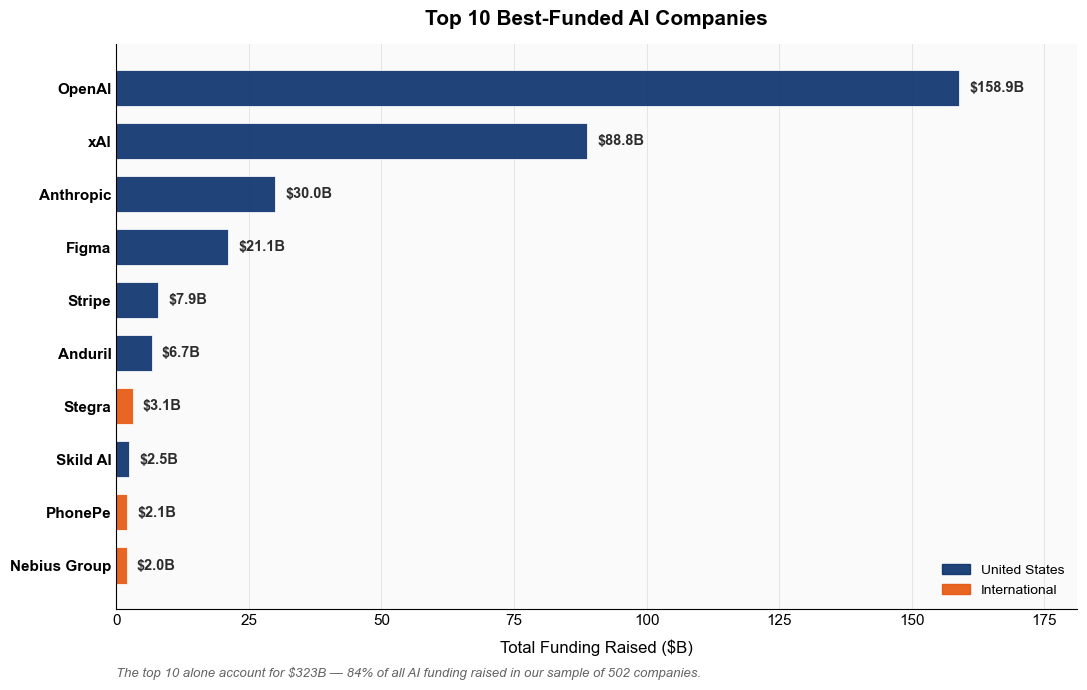

Saved: outputs/figures/02_top10_companies.png


In [41]:
top10 = df.nlargest(10, 'total_funding_millions').copy()
top10['funding_b'] = top10['total_funding_millions'] / 1_000
top10['bar_color'] = top10['headquarters_country'].apply(
    lambda c: NAVY if c == 'United States' else ORANGE
)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')

bars = ax.barh(
    top10['company_name'], top10['funding_b'],
    color=top10['bar_color'], alpha=0.90,
    edgecolor='white', linewidth=0.6, height=0.68
)

# All value labels OUTSIDE bars on the right (consistent placement, no collisions)
xmax = top10['funding_b'].max()
for bar, val in zip(bars, top10['funding_b']):
    ax.text(
        bar.get_width() + xmax * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.1f}B', va='center', ha='left',
        fontsize=10.5, fontweight='bold', color='#2c2c2c'
    )

ax.set_xlabel('Total Funding Raised ($B)', labelpad=8)
ax.set_title('Top 10 Best-Funded AI Companies', pad=14)
ax.invert_yaxis()
ax.set_xlim(0, xmax * 1.14)
ax.tick_params(axis='y', labelsize=11)
for label in ax.get_yticklabels():
    label.set_fontweight('bold')
ax.grid(axis='y', linewidth=0)

us_patch   = mpatches.Patch(color=NAVY,   alpha=0.90, label='United States')
intl_patch = mpatches.Patch(color=ORANGE, alpha=0.90, label='International')
ax.legend(handles=[us_patch, intl_patch], loc='lower right', fontsize=10)

# Caption with concentration insight
total_top10 = top10['funding_b'].sum()
total_all   = df['total_funding_millions'].sum() / 1_000
share = total_top10 / total_all
ax.text(
    0.0, -0.12,
    f'The top 10 alone account for ${total_top10:.0f}B — '
    f'{share:.0%} of all AI funding raised in our sample of {len(df)} companies.',
    transform=ax.transAxes, fontsize=9.5, color=GREY, style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/figures/02_top10_companies.png')
plt.show()
print('Saved: outputs/figures/02_top10_companies.png')

---
## Chart 3 — Global AI Funding Geography (Interactive)

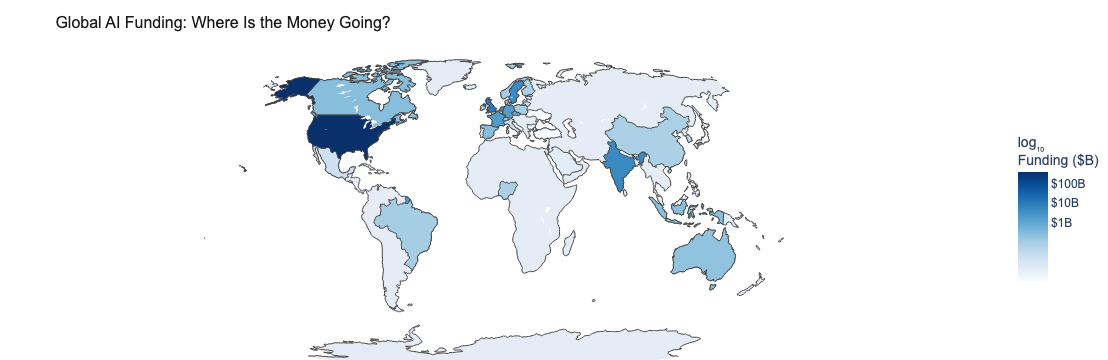


Top 10 countries by total funding:
       country  Total ($B)  Companies  Unicorns
 United States  358.319200        203        17
United Kingdom    9.625960         55         5
         India    4.469276         77         1
        Sweden    3.946900         12         1
   Netherlands    2.441100         11         1
        France    1.661400         14         0
       Germany    1.616700         17         0
     Singapore    1.511800         10         0
Czech Republic    0.817500          2         0
        Israel    0.373500          4         0


In [43]:
country_agg = (
    df.groupby('headquarters_country')
    .agg(
        total_funding_b=('total_funding_millions', lambda x: x.sum() / 1_000),
        num_companies=('company_name', 'count'),
        avg_funding_m=('total_funding_millions', 'mean'),
        unicorns=('is_unicorn', 'sum'),
    )
    .reset_index()
    .rename(columns={'headquarters_country': 'country'})
)
country_agg['log_funding'] = np.log10(country_agg['total_funding_b'].clip(lower=0.001))

fig = px.choropleth(
    country_agg,
    locations='country',
    locationmode='country names',
    color='log_funding',
    hover_name='country',
    hover_data={
        'total_funding_b': ':.1f',
        'num_companies': True,
        'avg_funding_m': ':.0f',
        'unicorns': True,
        'log_funding': False,
    },
    color_continuous_scale='Blues',
    labels={
        'total_funding_b': 'Total Funding ($B)',
        'num_companies':   'Companies',
        'avg_funding_m':   'Avg Funding ($M)',
        'unicorns':        'Unicorns',
        'log_funding':     'log\u2081\u2080(Funding $B)',
    },
    title='Global AI Funding: Where Is the Money Going?',
)
fig.update_layout(
    margin=dict(l=0, r=0, t=55, b=0),
    coloraxis_colorbar=dict(
        title='log\u2081\u2080<br>Funding ($B)',
        tickvals=[0, 1, 2, 3],
        ticktext=['$1B', '$10B', '$100B', '$1T'],
        len=0.55,
    ),
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='natural earth',
        bgcolor='white',
    ),
    font=dict(family='Arial', size=12),
    title_font=dict(size=16, color='#1a1a1a'),
    paper_bgcolor='white',
)
fig.write_html('../outputs/figures/03_geographic_map.html')
fig.show()

print('\nTop 10 countries by total funding:')
print(
    country_agg.nlargest(10, 'total_funding_b')
    [['country', 'total_funding_b', 'num_companies', 'unicorns']]
    .rename(columns={
        'total_funding_b': 'Total ($B)',
        'num_companies':   'Companies',
        'unicorns':        'Unicorns',
    })
    .to_string(index=False)
)

---
## Chart 4 — Which AI Sectors Attract the Most Capital?

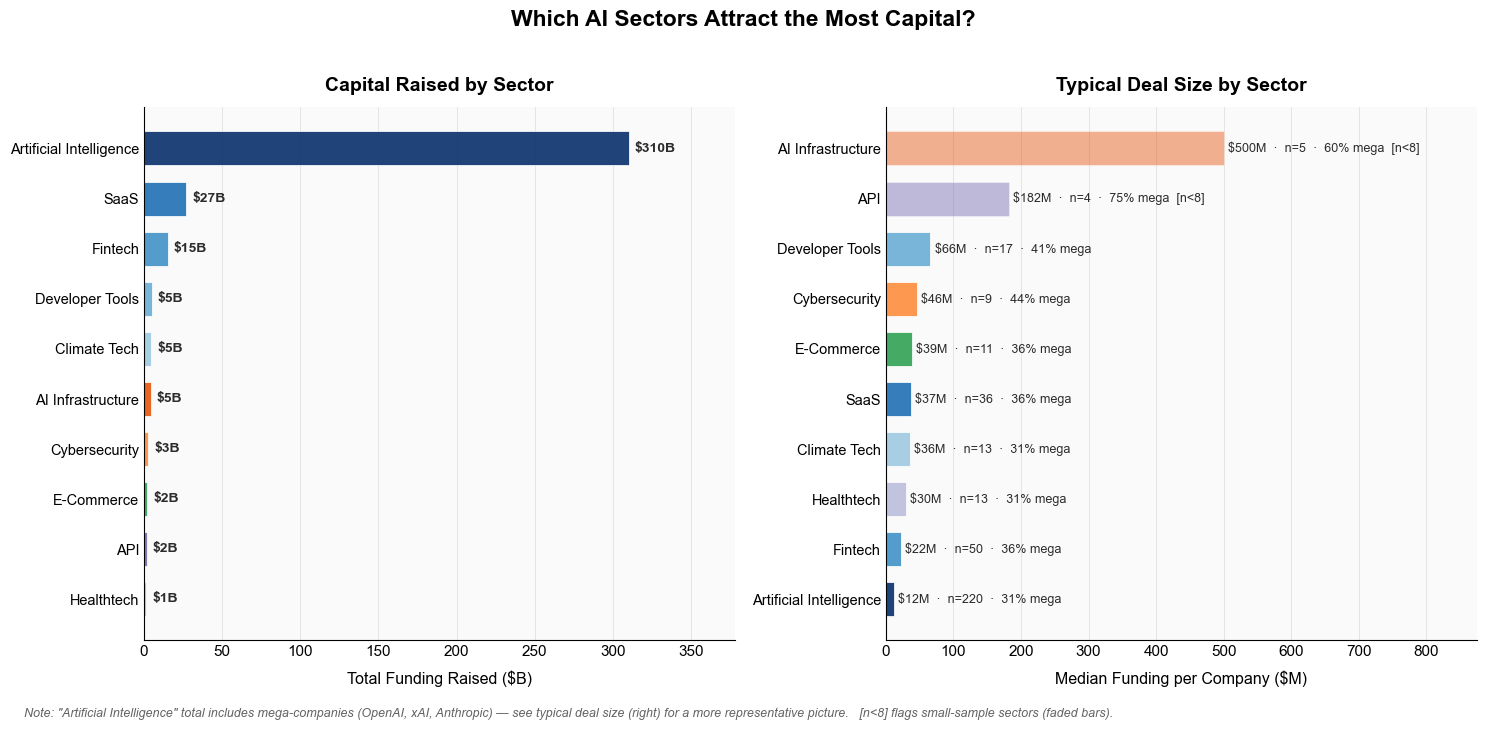

Saved: outputs/figures/04_sector_analysis.png


In [47]:
top_cats = (
    df.groupby('primary_category')['total_funding_millions']
    .sum().sort_values(ascending=False).head(10).index.tolist()
)

cat_df = (
    df[df['primary_category'].isin(top_cats)]
    .groupby('primary_category')
    .agg(
        total_b=('total_funding_millions',  lambda x: x.sum() / 1_000),
        median_m=('total_funding_millions', 'median'),
        count=('company_name',             'count'),
        pct_mega=('has_mega_round',         'mean'),
    )
    .reset_index()
)

# Stable colour mapping per category (consistent across both panels)
cat_df_for_colors = cat_df.sort_values('total_b', ascending=False).reset_index(drop=True)
color_map = {
    cat: CAT_COLORS[i % len(CAT_COLORS)]
    for i, cat in enumerate(cat_df_for_colors['primary_category'])
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.8))
fig.patch.set_facecolor('white')

# Left: Total capital 
cat_left = cat_df.sort_values('total_b', ascending=True)
bars_l = axes[0].barh(
    cat_left['primary_category'], cat_left['total_b'],
    color=[color_map[c] for c in cat_left['primary_category']],
    alpha=0.90, height=0.68, edgecolor='white', linewidth=0.6
)
for bar, val in zip(bars_l, cat_left['total_b']):
    axes[0].text(
        bar.get_width() + cat_left['total_b'].max() * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.0f}B', va='center', ha='left',
        fontsize=10, fontweight='bold', color='#2c2c2c'
    )
axes[0].set_xlabel('Total Funding Raised ($B)', fontsize=11.5, labelpad=8)
axes[0].set_title('Capital Raised by Sector', pad=12, fontsize=14)
axes[0].set_xlim(0, cat_left['total_b'].max() * 1.22)
axes[0].grid(axis='y', linewidth=0)
axes[0].tick_params(axis='y', labelsize=10.5)

# Right: Median deal size 
cat_right = cat_df.sort_values('median_m', ascending=True)
right_alpha = [0.45 if n < 8 else 0.90 for n in cat_right['count']]
bars_r = axes[1].barh(
    cat_right['primary_category'], cat_right['median_m'],
    color=[color_map[c] for c in cat_right['primary_category']],
    height=0.68, edgecolor='white', linewidth=0.6
)
for bar, a in zip(bars_r, right_alpha):
    bar.set_alpha(a)

for bar, val, cnt, pct in zip(
        bars_r, cat_right['median_m'],
        cat_right['count'], cat_right['pct_mega']):
    sample_flag = '  [n<8]' if cnt < 8 else ''
    axes[1].text(
        bar.get_width() + cat_right['median_m'].max() * 0.012,
        bar.get_y() + bar.get_height() / 2,
        f'${val:.0f}M  ·  n={cnt}  ·  {pct:.0%} mega{sample_flag}',
        va='center', ha='left', fontsize=9, color='#2c2c2c'
    )
axes[1].set_xlabel('Median Funding per Company ($M)', fontsize=11.5, labelpad=8)
axes[1].set_title('Typical Deal Size by Sector', pad=12, fontsize=14)
axes[1].set_xlim(0, cat_right['median_m'].max() * 1.75)
axes[1].grid(axis='y', linewidth=0)
axes[1].tick_params(axis='y', labelsize=10.5)

plt.suptitle('Which AI Sectors Attract the Most Capital?',
             fontsize=16.5, fontweight='bold', y=1.02)

fig.text(
    0.02, -0.02,
    'Note: "Artificial Intelligence" total includes mega-companies (OpenAI, xAI, Anthropic) — '
    'see typical deal size (right) for a more representative picture.   '
    '[n<8] flags small-sample sectors (faded bars).',
    fontsize=9, color=GREY, style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/figures/04_sector_analysis.png', bbox_inches='tight')
plt.show()
print('Saved: outputs/figures/04_sector_analysis.png')